In [2]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math
import random

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 91.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=ef1f3c0cbef6e7020be5d77563bdfbf9d6b611294d8161a50c8cf85e01cdba01
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


--- BB84 Protocol Simulation ---
Alice's bits:  [0, 0, 0, 0, 0, 1, 1, 0, 0, 0]
Alice's bases: ['d', 'd', 'd', 'd', 'd', 's', 's', 'd', 's', 's']
Bob's bases:   ['d', 's', 's', 'd', 's', 'd', 's', 's', 'd', 's']
Bob's bits:    [0, 1, 0, 0, 0, 1, 1, 1, 1, 0]
--------------------------------------------------
Match markers: ['|', ' ', ' ', '|', ' ', ' ', '|', ' ', ' ', '|']
Shared Key:    [0, 0, 1, 0]
Key Length:    4 bits (approx. half of 10)


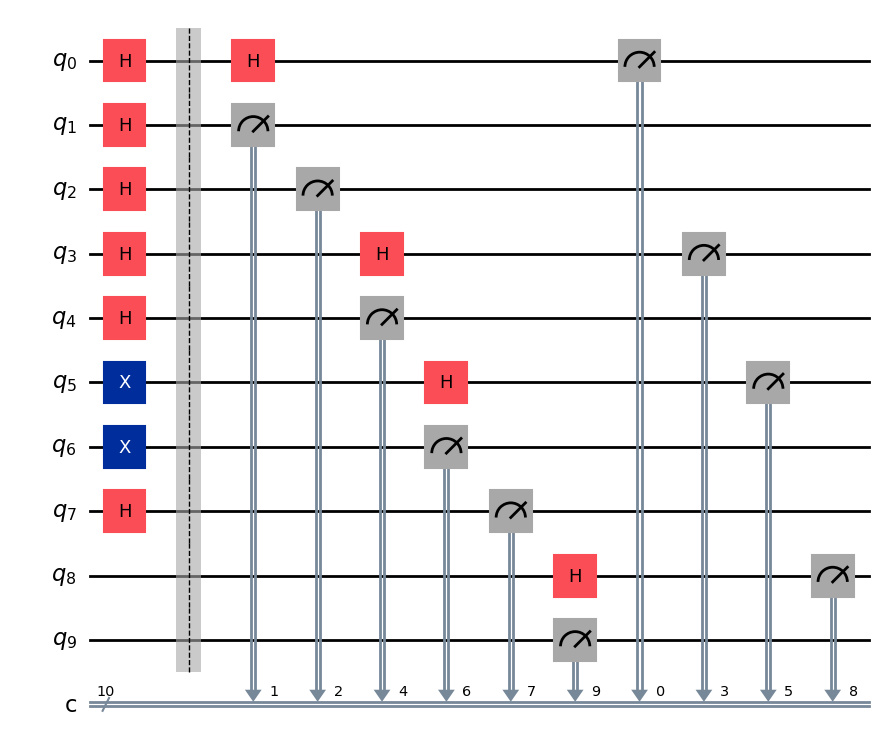

In [3]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# This notebook is for a simulation of the protocol without an attacker.

# Define the number of qubits to send
n = 10

# 1. Alice generates a random sequence of bits
alice_bits = [random.randint(0, 1) for _ in range(n)]

# 2. Alice chooses a random basis for each bit
# 's' for standard basis (|0>, |1>), 'd' for diagonal basis (|+>, |->)
alice_bases = [random.choice(['s', 'd']) for _ in range(n)]

# 3. Bob chooses a random basis for measuring each qubit he will receive
bob_bases = [random.choice(['s', 'd']) for _ in range(n)]

# Create a quantum circuit with n qubits and n classical bits
bb84 = QuantumCircuit(n, n)

# 4. Alice prepares her qubits
for i in range(n):
    # If Alice wants to send a 1, apply an X gate to flip |0> to |1>
    if alice_bits[i] == 1:
        bb84.x(i)

    # If Alice is using the diagonal basis, apply a Hadamard (H) gate
    # |0> becomes |+> and |1> becomes |->
    if alice_bases[i] == 'd':
        bb84.h(i)

# Add a barrier to visually separate Alice's preparation from Bob's measurement
bb84.barrier()

# 5. Bob receives the qubits and measures them
for i in range(n):
    # If Bob decides to measure in the diagonal basis, he applies an H gate before measuring
    if bob_bases[i] == 'd':
        bb84.h(i)

    # Measure qubit i into classical bit i
    bb84.measure(i, i)

# 6. Simulate the circuit
backend = BasicSimulator()
compiled = transpile(bb84, backend)

# We only need 1 shot because this is a single execution of the protocol
job_sim = backend.run(compiled, shots=1)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)

# The result is a single bitstring. Qiskit orders classical bits right-to-left,
# so we reverse it to match our 0 to n-1 indexing.
measured_str = list(counts.keys())[0][::-1]
bob_bits = [int(b) for b in measured_str]

# 7. Sifting: Alice and Bob publicly compare their bases.
# They keep the bits only where their bases matched.
shared_key = []
for i in range(n):
    if alice_bases[i] == bob_bases[i]:
        shared_key.append(alice_bits[i])

# 8. Results
print("--- BB84 Protocol Simulation ---")
print(f"Alice's bits:  {alice_bits}")
print(f"Alice's bases: {alice_bases}")
print(f"Bob's bases:   {bob_bases}")
print(f"Bob's bits:    {bob_bits}")
print("-" * 50)

# Display the matched positions
matches = ['|' if alice_bases[i] == bob_bases[i] else ' ' for i in range(n)]
print(f"Match markers: {matches}")
print(f"Shared Key:    {shared_key}")
print(f"Key Length:    {len(shared_key)} bits (approx. half of {n})")


bb84.draw("mpl")